# Cluster HFpEF

In [1]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sn

from IPython.display import display

from preproc import get_hfpef_200, convert2np

In [2]:
no_clusters = 8
lbl_colname= ['Death', 'CV death', 'Major cardiac events']

## Get Data

In [3]:
data_df = get_hfpef_200()

In [5]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   200 non-null    int64  
 1   Sex                   200 non-null    int64  
 2   Cr                    200 non-null    float64
 3   GFR                   200 non-null    float64
 4   CKD stage             200 non-null    int64  
 5   smoke                 200 non-null    float64
 6   BMI                   200 non-null    float64
 7   BSA                   200 non-null    float64
 8   DM                    200 non-null    int64  
 9   Insulin               200 non-null    int64  
 10  AF                    200 non-null    int64  
 11  SBP                   200 non-null    int64  
 12  DBP                   200 non-null    int64  
 13  MAP                   200 non-null    float64
 14  PP                    200 non-null    int64  
 15  1/2SBP                2

In [6]:
data_df.describe()

,Age,Sex,Cr,GFR,CKD stage,smoke,BMI,BSA,DM,Insulin,...,E/A,Mitral E/e',TR Vmax,RWT,LV mass index,LVH,LAVI,LACI,LA diameter,LVEF
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,72.045000,1.680000,1.711100,52.293250,2.810000,0.105000,26.738830,1.632980,0.560000,0.215000,...,0.741571,17.300650,1.890100,0.648305,115.640950,2.640000,31.987000,3.211636,3.670264,61.434500
std,11.404529,0.467647,1.534721,25.188572,1.043718,0.307323,6.636857,0.228277,0.497633,0.411853,...,0.606755,8.602117,1.443655,0.388423,52.778994,1.896943,26.285226,3.988946,1.446008,8.420635
min,31.000000,1.000000,0.550000,2.000000,1.000000,0.000000,15.400000,1.120000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,65.000000,1.000000,0.887500,34.750000,2.000000,0.000000,22.200000,1.485000,0.000000,0.000000,...,0.500000,11.600000,0.000000,0.400000,86.725000,1.000000,0.000000,0.000000,3.500000,56.000000
50%,74.000000,2.000000,1.140000,54.000000,3.000000,0.000000,26.300000,1.600000,1.000000,0.000000,...,0.700000,16.300000,2.460000,0.555000,113.150000,2.500000,32.600000,2.479869,4.000000,61.000000
75%,80.000000,2.000000,1.792500,70.250000,3.000000,0.000000,29.925000,1.800000,1.000000,0.000000,...,1.000000,22.100000,3.002500,0.865000,141.305000,4.000000,48.425000,5.111374,4.400000,66.000000
max,97.000000,2.000000,10.000000,108.000000,5.000000,1.000000,55.900000,2.300000,1.000000,1.000000,...,4.100000,42.200000,4.550000,2.300000,356.600000,7.000000,140.800000,23.665480,6.200000,82.900000


## 1. All Features

In [7]:
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.mixture import GaussianMixture

from sklearn.pipeline import make_pipeline

from utils import get_score, score_columns, plot_contingency_matrix, plot_bic_aic, plot_clustering_score

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')

In [8]:
X, y, feature_list = convert2np(data_df, lbl_colname)

In [9]:
def get_km_pred(k, X):
    km = KMeans(n_clusters=k, random_state=0)
    return km.fit_predict(X)

def get_sc_pred(k, X):
    sc = SpectralClustering(n_clusters=k, eigen_solver='arpack', affinity="nearest_neighbors", random_state=0)
    return sc.fit_predict(X)

def get_gm_pred(k, X):
    gm = GaussianMixture(n_components=k, random_state=0, init_params='kmeans').fit(X)
    return gm.predict(X)

In [10]:
all_dfs = []
for f in [get_sc_pred, get_km_pred, get_gm_pred]:
    dfs = []
    for i in range(y.shape[1]):
        df = pd.DataFrame([get_score(k, f, X, y[:,i]) for k in range(2, no_clusters)],
                          columns=score_columns)
        dfs.append(df)
    all_dfs.append(dfs)

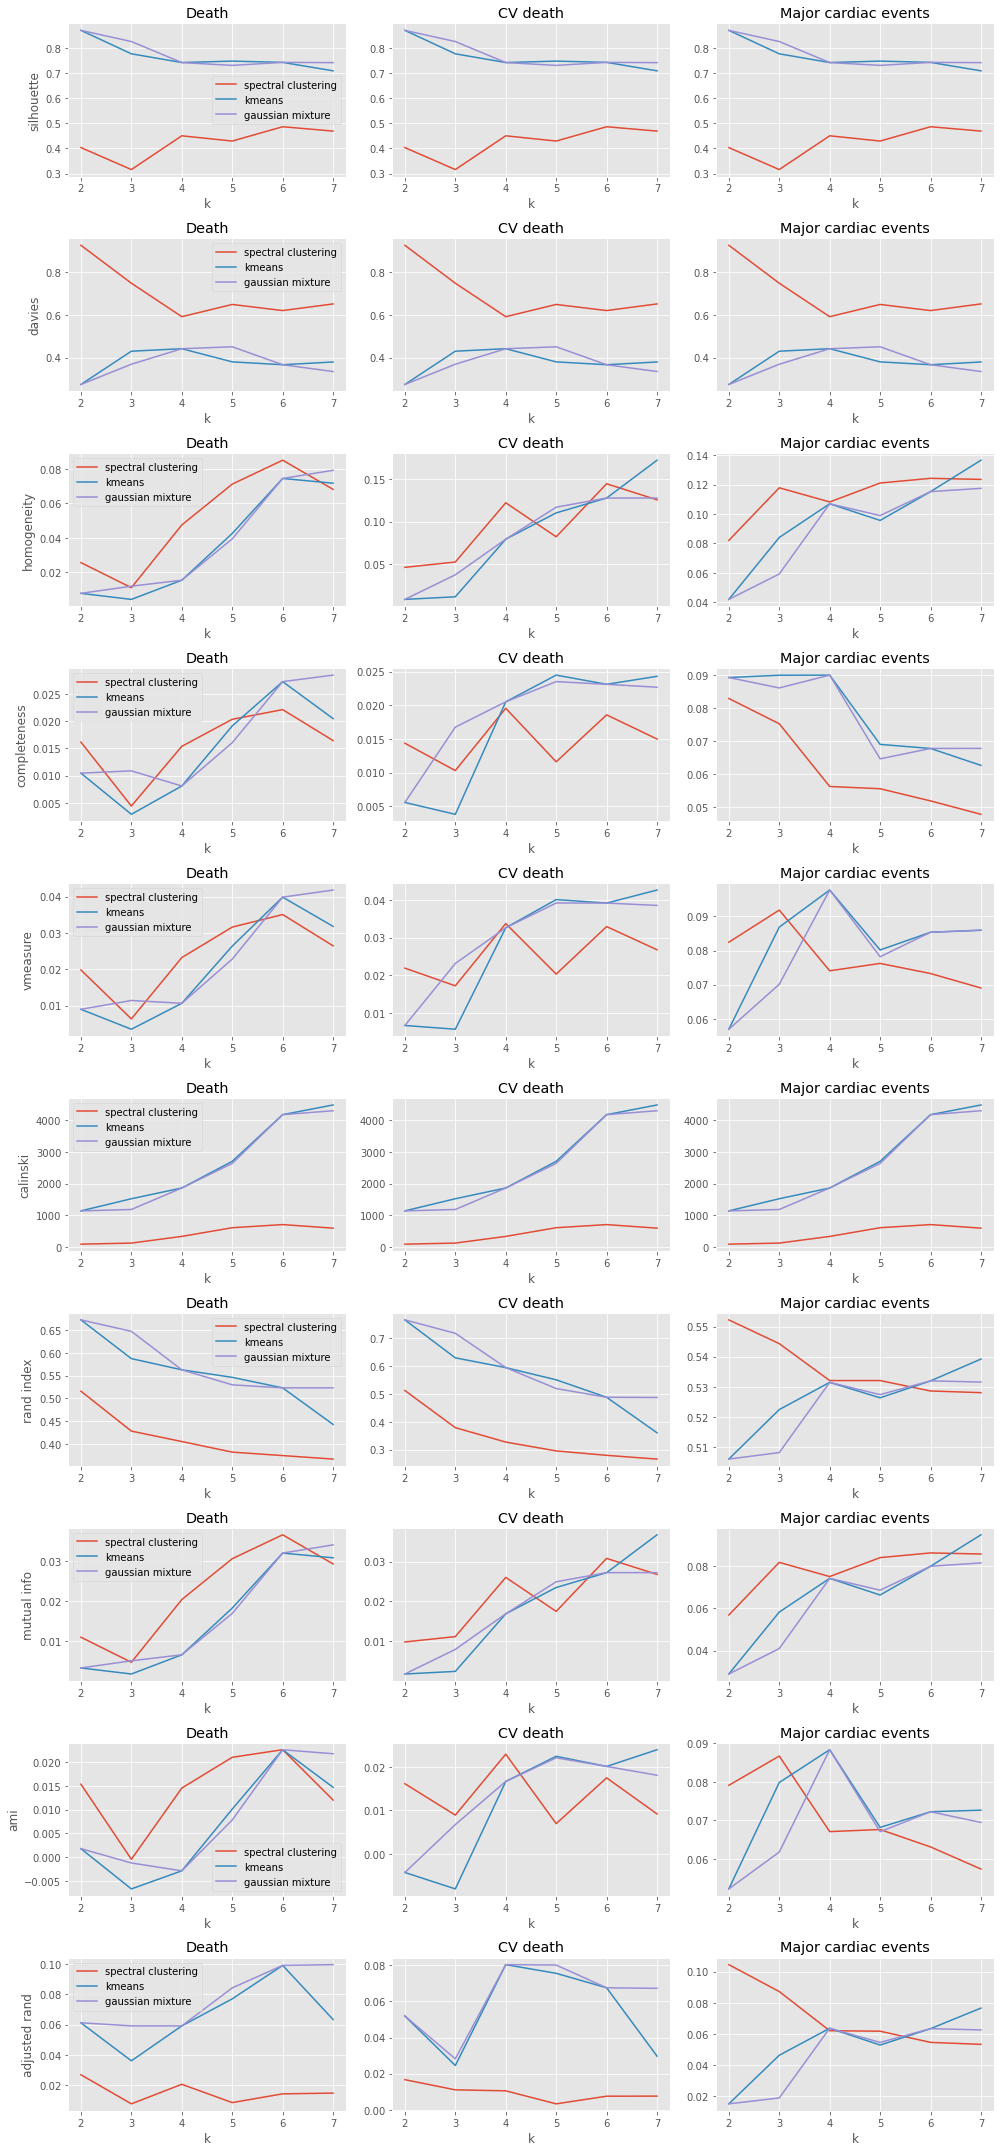

In [11]:
methods = ['spectral clustering', 'kmeans', 'gaussian mixture']

plot_clustering_score(all_dfs, methods, lbl_colname)

The meaning of the scores.
<!-- * `BIC` lower is better
* `AIC` lower is better -->
* `silhouette` higher is better
* `davies` lower is better
* `homogeneity` higher is better
* `completeness` higher is better
* `v-measure` higher is better
* `calinski` higher is better
* `v-measure` higher is better
* `calinski` higher is better
* `rand index` higher is better
* `mutual info` higher is better

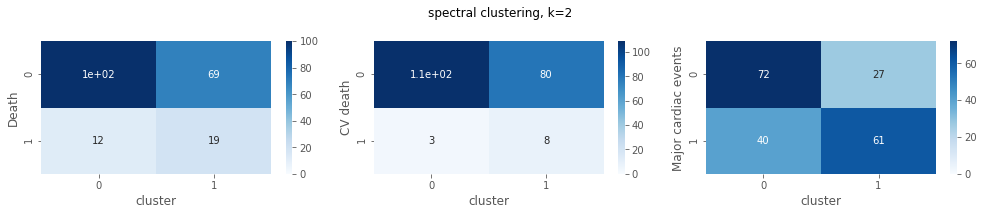

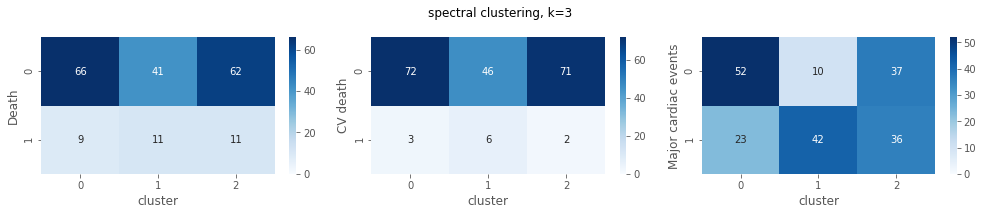

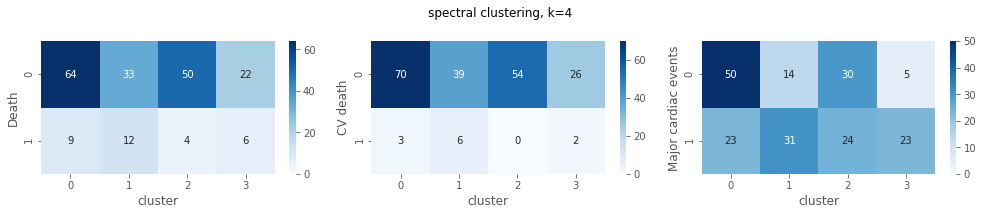

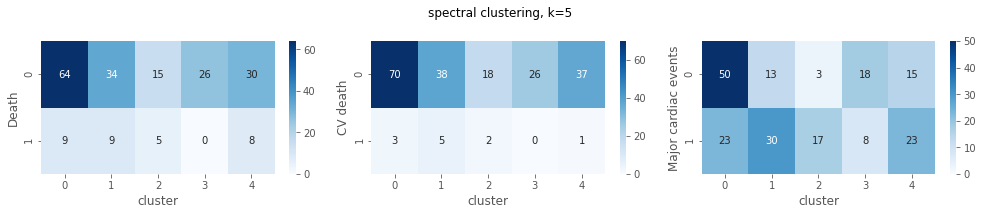

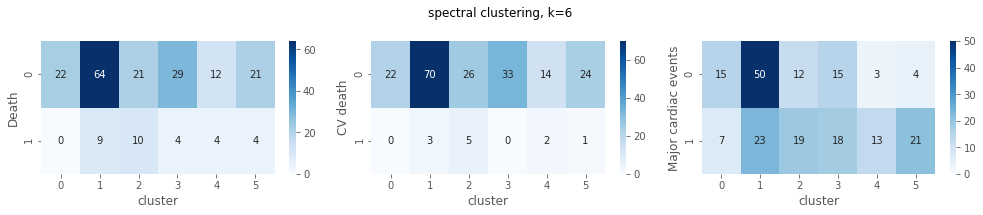

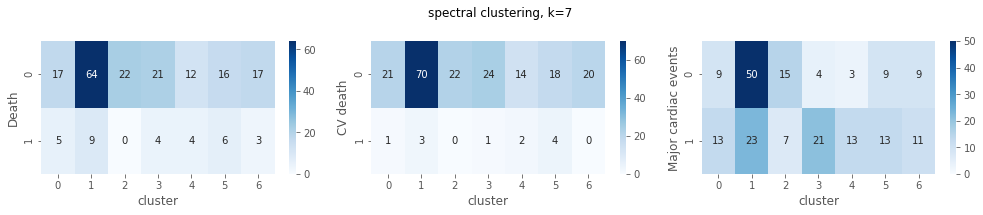

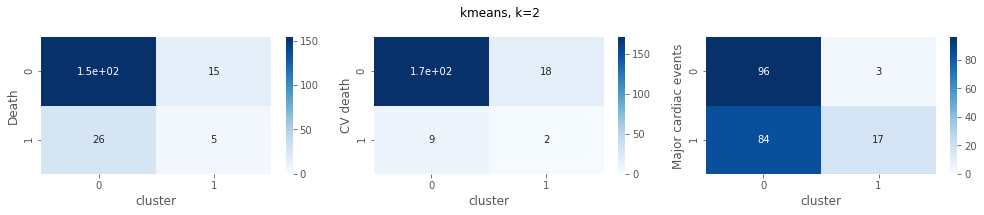

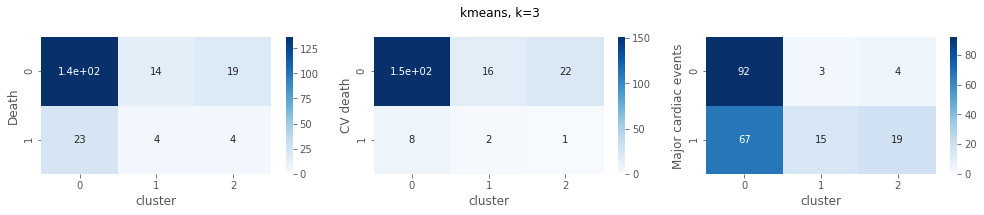

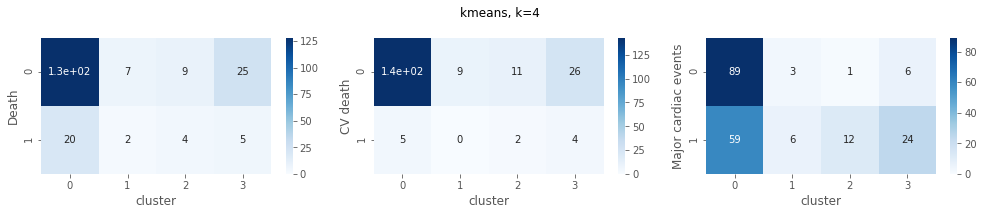

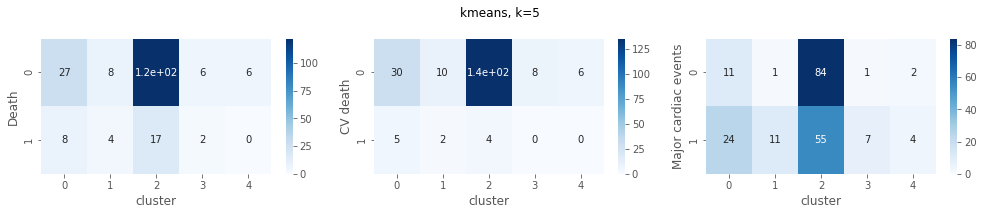

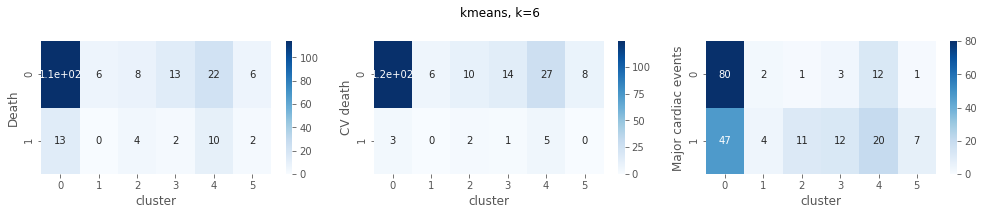

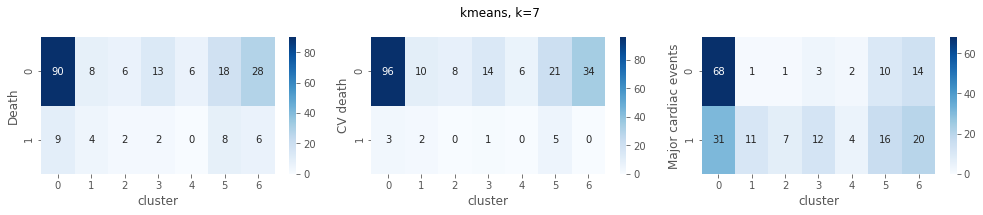

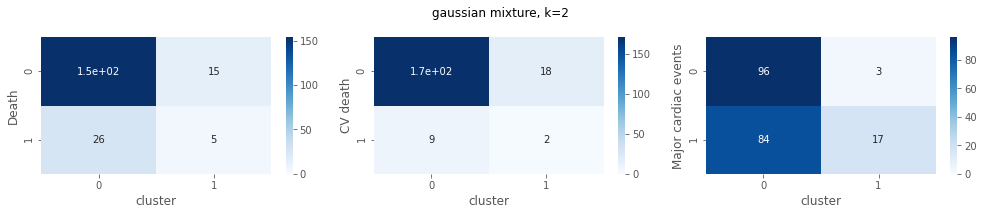

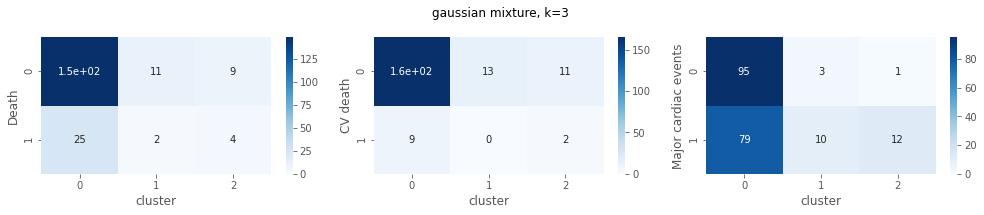

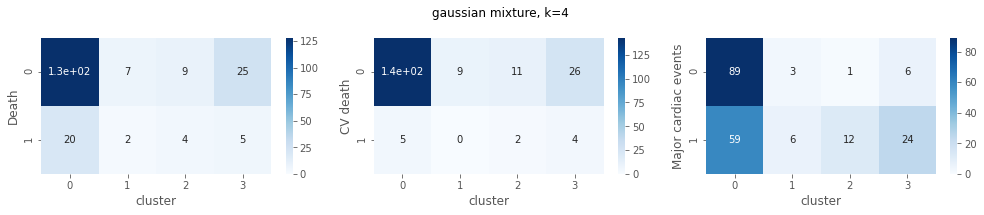

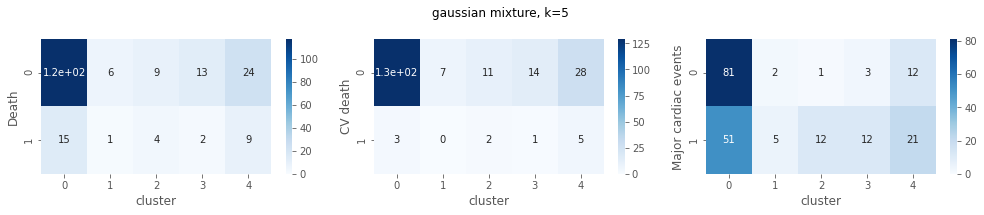

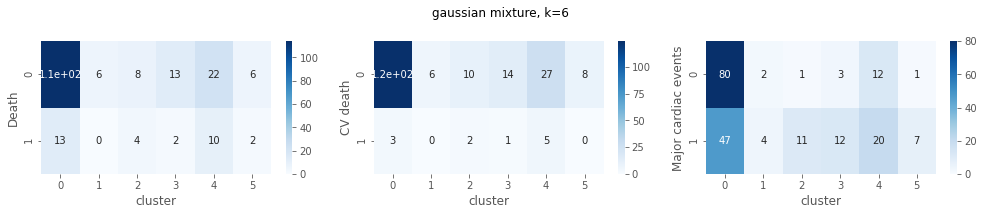

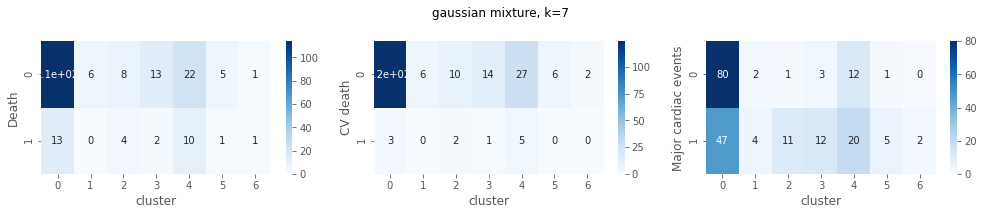

In [12]:
plot_contingency_matrix(all_dfs, methods, lbl_colname)

In [13]:
for i, lbl in enumerate(lbl_colname):
    display(lbl)
    for j, met in enumerate(methods):
        display(met)
        display(all_dfs[j][i])

'Death'

'spectral clustering'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.403353,0.925512,0.025657,0.016132,0.019809,90.501255,0.515628,0.011065,0.015324,0.026904,"[[100, 69], [12, 19]]","[112, 88]"
1,3,0.315817,0.747932,0.011151,0.004429,0.006340,124.458152,0.427839,0.004809,-0.000416,0.007759,"[[66, 41, 62], [9, 11, 11]]","[75, 52, 73]"
2,4,0.450255,0.591132,0.047460,0.015364,0.023213,334.985671,0.404925,0.020469,0.014516,0.020634,"[[64, 33, 50, 22], [9, 12, 4, 6]]","[73, 45, 54, 28]"
3,5,0.429347,0.648434,0.071103,0.020317,0.031603,608.955121,0.381608,0.030666,0.020966,0.008580,"[[64, 34, 15, 26, 30], [9, 9, 5, 0, 8]]","[73, 43, 20, 26, 38]"
4,6,0.486363,0.619826,0.084945,0.022084,0.035054,707.806029,0.374020,0.036636,0.022554,0.014349,"[[22, 64, 21, 29, 12, 21], [0, 9, 10, 4, 4, 4]]","[22, 73, 31, 33, 16, 25]"
5,7,0.469040,0.650897,0.068071,0.016415,0.026451,595.205956,0.366332,0.029358,0.012001,0.014828,"[[17, 64, 22, 21, 12, 16, 17], [5, 9, 0, 4, 4,...","[22, 73, 22, 25, 16, 22, 20]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.870168,0.273688,0.007875,0.010448,0.008981,1139.852901,0.672412,0.003396,0.001817,0.061134,"[[154, 15], [26, 5]]","[180, 20]"
1,3,0.776811,0.429560,0.004372,0.002910,0.003494,1522.962046,0.587236,0.001885,-0.006622,0.036091,"[[136, 14, 19], [23, 4, 4]]","[159, 18, 23]"
2,4,0.742016,0.441185,0.015486,0.008099,0.010636,1861.510836,0.562613,0.006679,-0.002828,0.059097,"[[128, 7, 9, 25], [20, 2, 4, 5]]","[148, 9, 13, 30]"
3,5,0.747726,0.379492,0.042540,0.019099,0.026362,2702.888954,0.546030,0.018347,0.010111,0.076906,"[[27, 8, 122, 6, 6], [8, 4, 17, 2, 0]]","[35, 12, 139, 8, 6]"
4,6,0.742639,0.366174,0.074365,0.027212,0.039844,4174.848635,0.522915,0.032072,0.022545,0.098953,"[[114, 6, 8, 13, 22, 6], [13, 0, 4, 2, 10, 2]]","[127, 6, 12, 15, 32, 8]"
5,7,0.709011,0.379026,0.071632,0.020438,0.031803,4480.787660,0.442513,0.030894,0.014672,0.063275,"[[90, 8, 6, 13, 6, 18, 28], [9, 4, 2, 2, 0, 8,...","[99, 12, 8, 15, 6, 26, 34]"


...

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.403353,0.925512,0.082008,0.082865,0.082435,90.501255,0.552211,0.056840,0.079070,0.104464,"[[72, 27], [40, 61]]","[112, 88]"
1,3,0.315817,0.747932,0.117871,0.075233,0.091844,124.458152,0.544322,0.081696,0.086657,0.087188,"[[52, 10, 37], [23, 42, 36]]","[75, 52, 73]"
2,4,0.450255,0.591132,0.108209,0.056295,0.074060,334.985671,0.532060,0.075000,0.067050,0.062021,"[[50, 14, 30, 5], [23, 31, 24, 23]]","[73, 45, 54, 28]"
3,5,0.429347,0.648434,0.121112,0.055614,0.076225,608.955121,0.532060,0.083942,0.067596,0.061705,"[[50, 13, 3, 18, 15], [23, 30, 17, 8, 23]]","[73, 43, 20, 26, 38]"
4,6,0.486363,0.619826,0.124311,0.051937,0.073264,707.806029,0.528593,0.086160,0.063074,0.054529,"[[15, 50, 12, 15, 3, 4], [7, 23, 19, 18, 13, 21]]","[22, 73, 31, 33, 16, 25]"
5,7,0.469040,0.650897,0.123574,0.047888,0.069026,595.205956,0.528040,0.085648,0.057329,0.053260,"[[9, 50, 15, 4, 3, 9, 9], [13, 23, 7, 21, 13, ...","[22, 73, 22, 25, 16, 22, 20]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.870168,0.273688,0.041834,0.089194,0.056955,1139.852901,0.505980,0.028995,0.052175,0.015055,"[[96, 3], [84, 17]]","[180, 20]"
1,3,0.776811,0.429560,0.084012,0.089883,0.086848,1522.962046,0.522412,0.058228,0.079802,0.046248,"[[92, 3, 4], [67, 15, 19]]","[159, 18, 23]"
2,4,0.742016,0.441185,0.106978,0.089917,0.097708,1861.510836,0.531457,0.074146,0.088307,0.063599,"[[89, 3, 1, 6], [59, 6, 12, 24]]","[148, 9, 13, 30]"
3,5,0.747726,0.379492,0.095637,0.069001,0.080165,2702.888954,0.526332,0.066286,0.068143,0.052825,"[[11, 1, 84, 1, 2], [24, 11, 55, 7, 4]]","[35, 12, 139, 8, 6]"
4,6,0.742639,0.366174,0.115247,0.067772,0.085352,4174.848635,0.531960,0.079877,0.072202,0.063345,"[[80, 2, 1, 3, 12, 1], [47, 4, 11, 12, 20, 7]]","[127, 6, 12, 15, 32, 8]"
5,7,0.709011,0.379026,0.136657,0.062661,0.085924,4480.787660,0.539196,0.094717,0.072619,0.076564,"[[68, 1, 1, 3, 2, 10, 14], [31, 11, 7, 12, 4, ...","[99, 12, 8, 15, 6, 26, 34]"


'gaussian mixture'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.870168,0.273688,0.041834,0.089194,0.056955,1139.852901,0.505980,0.028995,0.052175,0.015055,"[[96, 3], [84, 17]]","[180, 20]"
1,3,0.825693,0.368488,0.059158,0.086049,0.070113,1184.181161,0.508141,0.041002,0.061742,0.018834,"[[95, 3, 1], [79, 10, 12]]","[174, 13, 13]"
2,4,0.742016,0.441185,0.106978,0.089917,0.097708,1861.510836,0.531457,0.074146,0.088307,0.063599,"[[89, 3, 1, 6], [59, 6, 12, 24]]","[148, 9, 13, 30]"
3,5,0.730633,0.450178,0.098924,0.064633,0.078184,2637.160928,0.527387,0.068564,0.067027,0.054506,"[[81, 2, 1, 3, 12], [51, 5, 12, 12, 21]]","[132, 7, 13, 15, 33]"
4,6,0.742639,0.366174,0.115247,0.067772,0.085352,4174.848635,0.531960,0.079877,0.072202,0.063345,"[[80, 2, 1, 3, 12, 1], [47, 4, 11, 12, 20, 7]]","[127, 6, 12, 15, 32, 8]"
5,7,0.741594,0.334323,0.117489,0.067797,0.085979,4298.799051,0.531558,0.081431,0.069431,0.062535,"[[80, 2, 1, 3, 12, 1, 0], [47, 4, 11, 12, 20, ...","[127, 6, 12, 15, 32, 6, 2]"


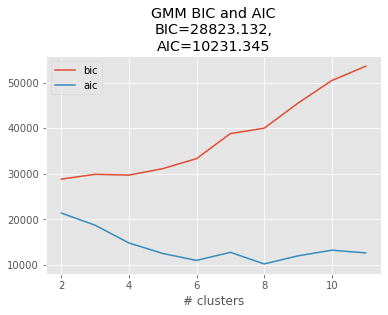

In [14]:
bics, aics = plot_bic_aic(X)

## 2. Selected Feature

In [15]:
X, y, feature_list = convert2np(data_df, lbl_colname, selected_feat=True)

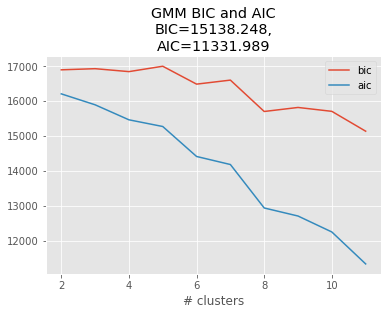

In [16]:
bics, aics = plot_bic_aic(X)

In [17]:
all_dfs = []
for f in [get_sc_pred, get_km_pred, get_gm_pred]:
    dfs = []
    for i in range(y.shape[1]):
        df = pd.DataFrame([get_score(k, f, X, y[:,i]) for k in range(2, no_clusters)],
                          columns=score_columns)
        dfs.append(df)
    all_dfs.append(dfs)

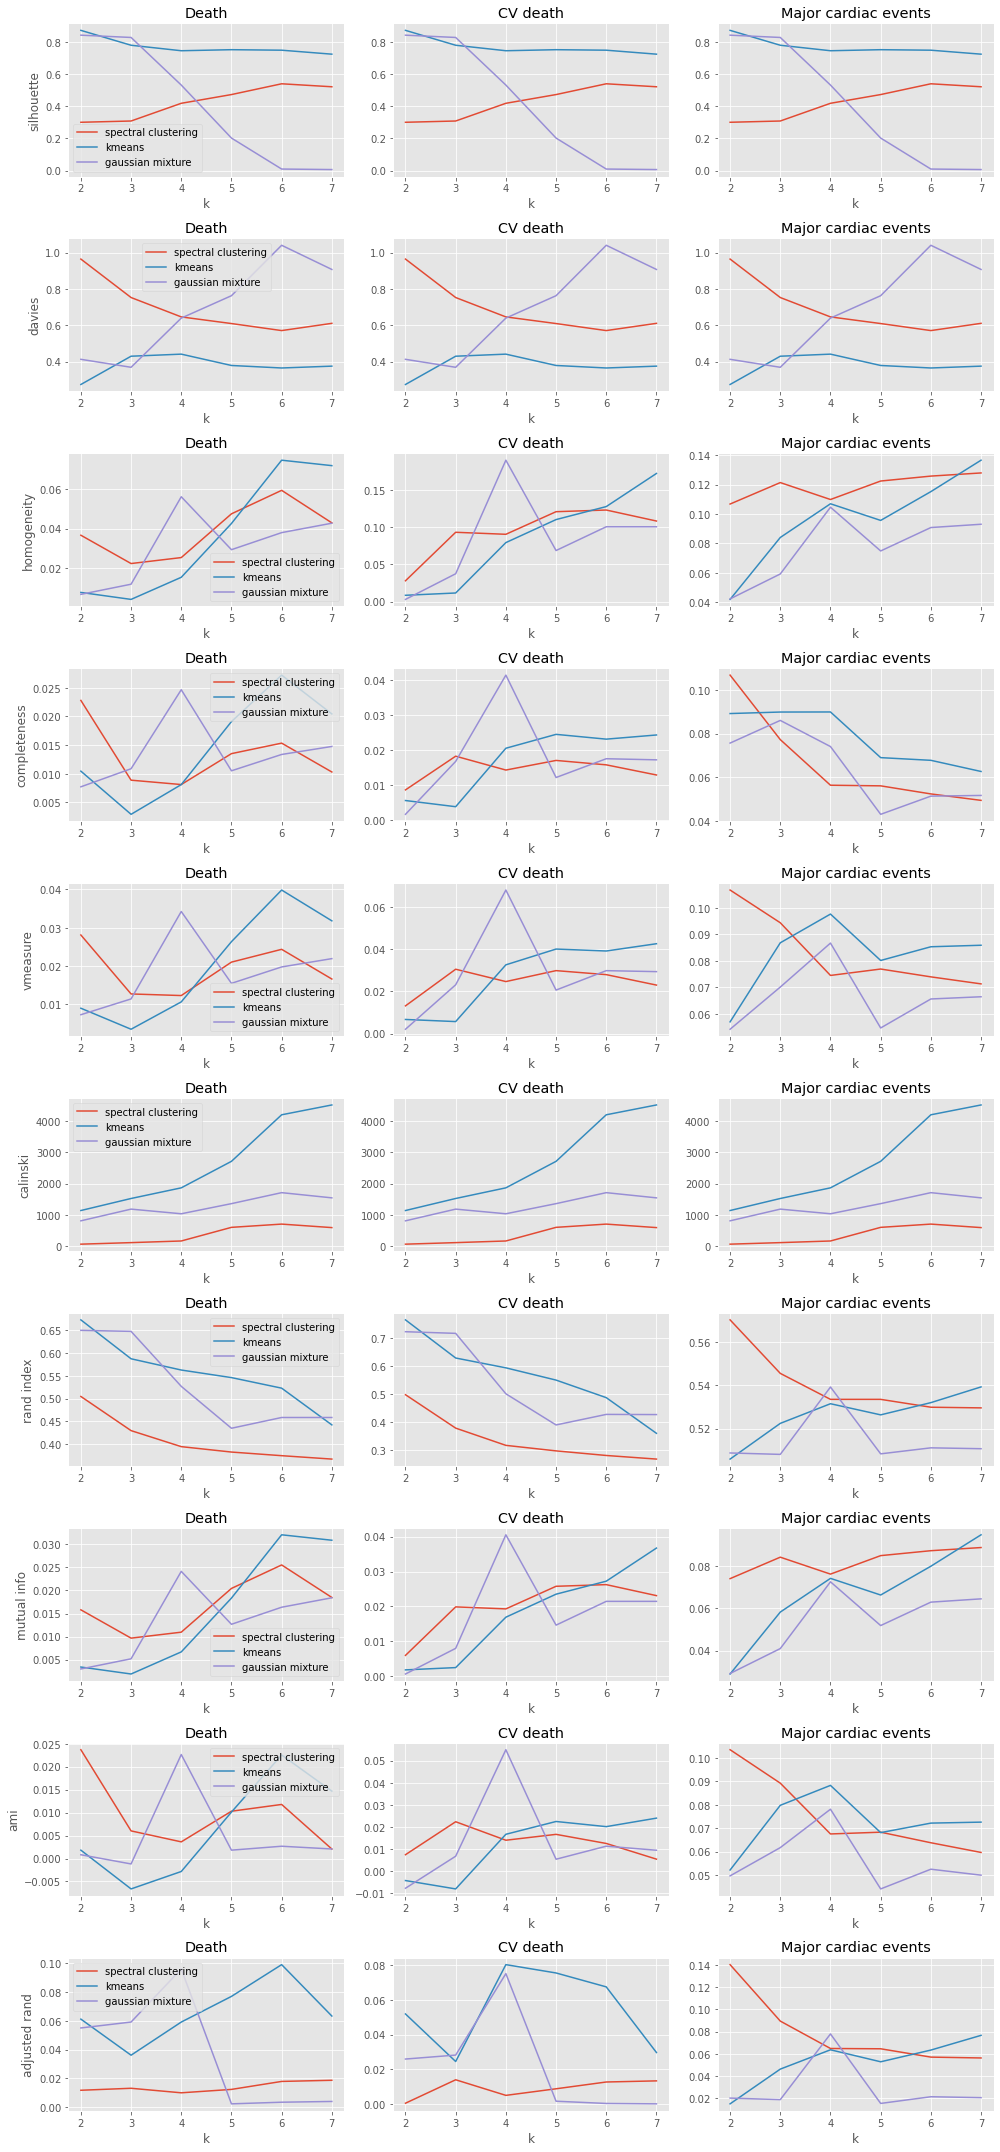

In [18]:
methods = ['spectral clustering', 'kmeans', 'gaussian mixture']

plot_clustering_score(all_dfs, methods, lbl_colname)

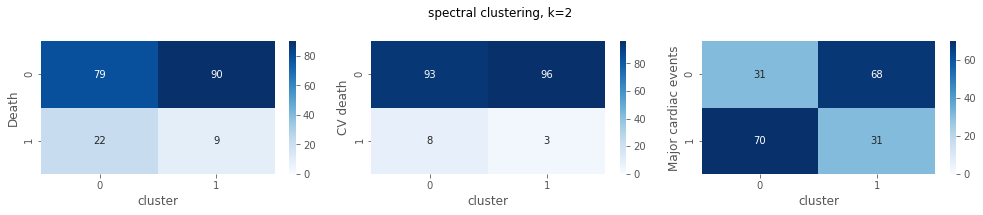

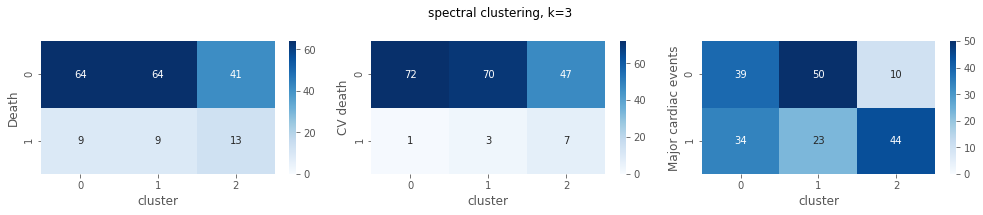

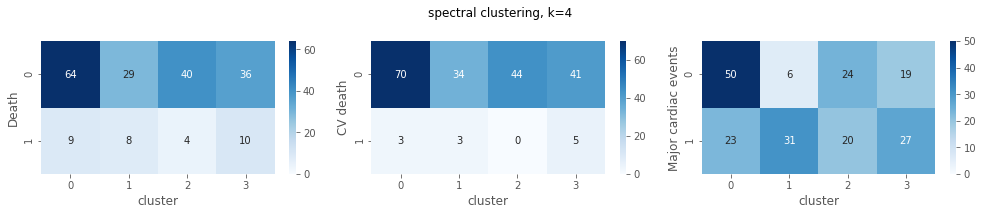

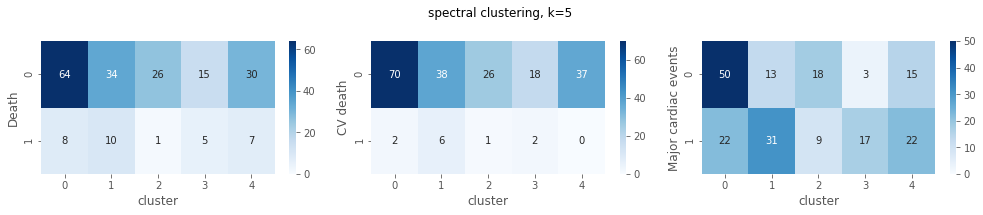

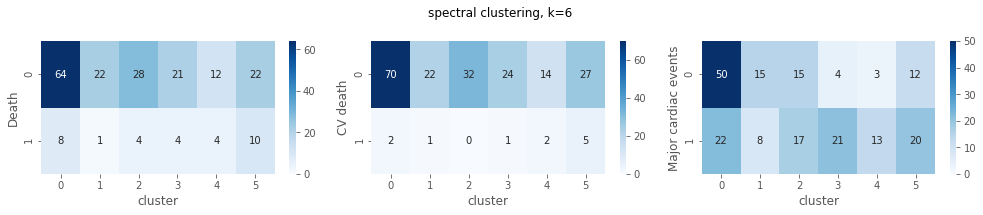

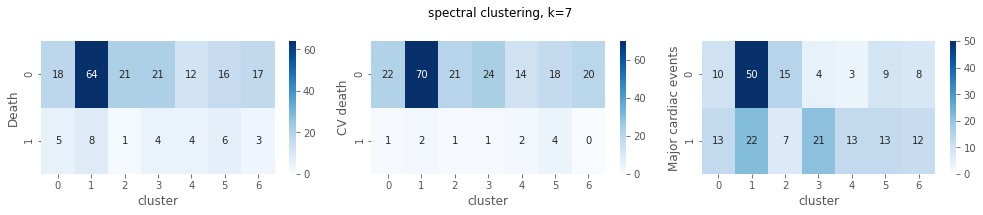

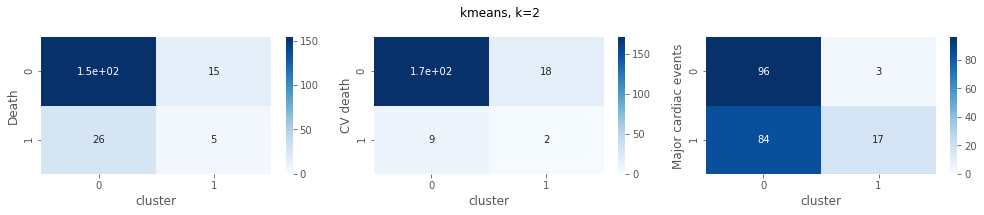

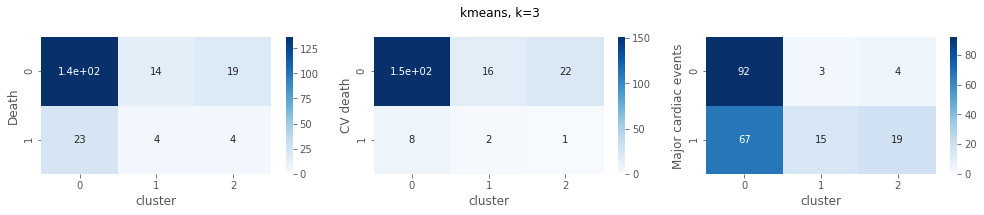

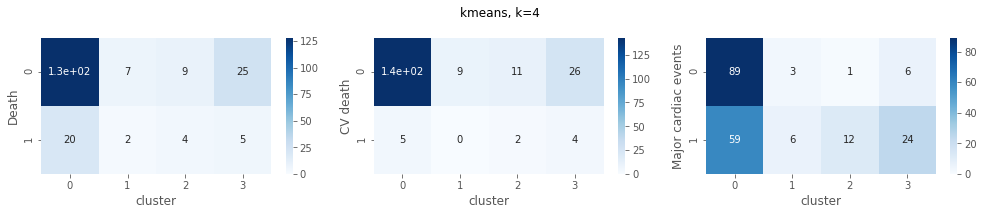

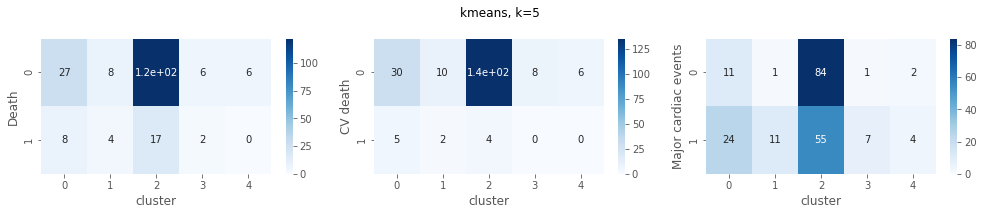

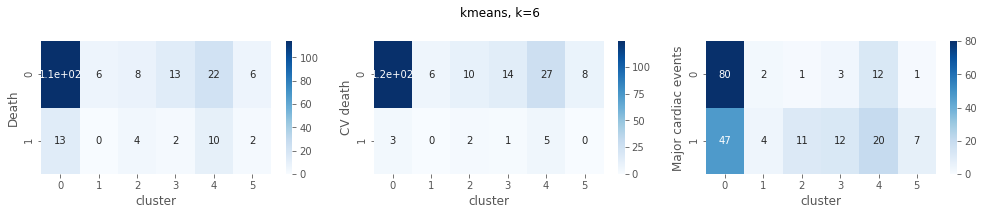

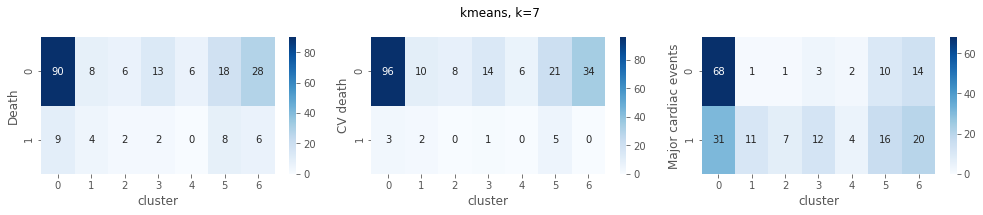

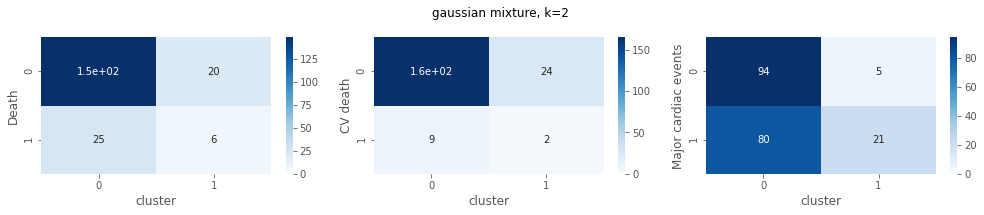

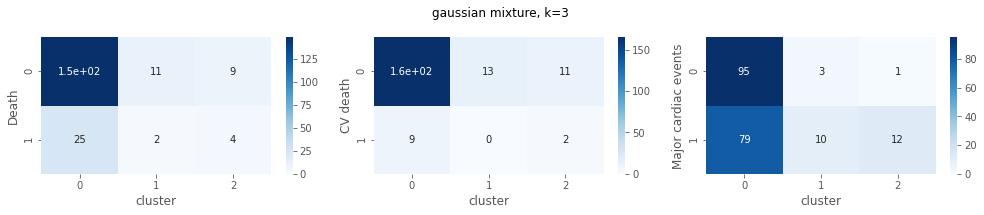

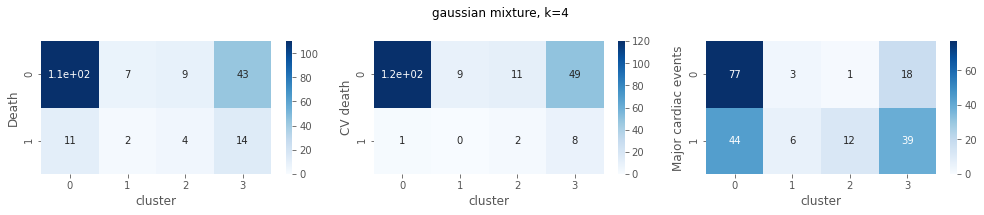

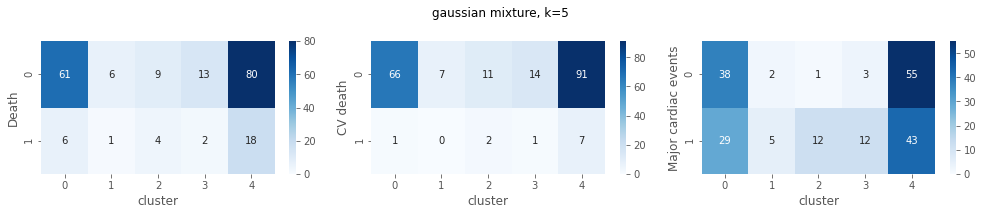

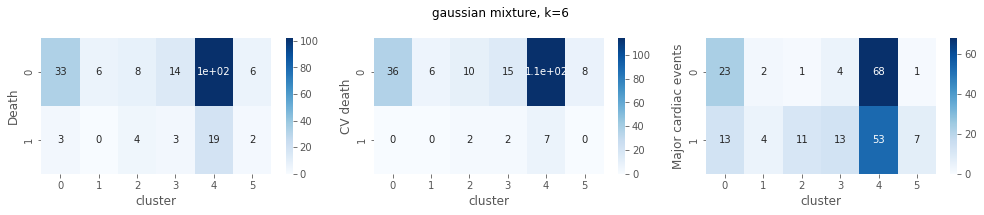

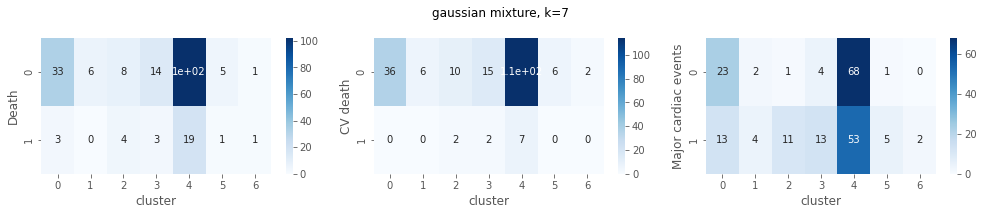

In [19]:
plot_contingency_matrix(all_dfs, methods, lbl_colname)

In [20]:
for i, lbl in enumerate(lbl_colname):
    display(lbl)
    for j, met in enumerate(methods):
        display(met)
        display(all_dfs[j][i])

'Death'

'spectral clustering'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.299744,0.964069,0.036637,0.022797,0.028106,66.960878,0.504724,0.015801,0.023689,0.011751,"[[79, 90], [22, 9]]","[101, 99]"
1,3,0.307582,0.752343,0.022406,0.008871,0.012710,116.104799,0.429950,0.009663,0.006014,0.013130,"[[64, 64, 41], [9, 9, 13]]","[73, 73, 54]"
2,4,0.417596,0.645637,0.025403,0.008108,0.012293,168.214159,0.394874,0.010956,0.003625,0.009986,"[[64, 29, 40, 36], [9, 8, 4, 10]]","[73, 37, 44, 46]"
3,5,0.471819,0.609087,0.047398,0.013505,0.021021,603.340248,0.383015,0.020442,0.010298,0.012343,"[[64, 34, 26, 15, 30], [8, 10, 1, 5, 7]]","[72, 44, 27, 20, 37]"
4,6,0.538760,0.570378,0.059208,0.015337,0.024364,707.184592,0.375075,0.025536,0.011773,0.017887,"[[64, 22, 28, 21, 12, 22], [8, 1, 4, 4, 4, 10]]","[72, 23, 32, 25, 16, 32]"
5,7,0.520236,0.610241,0.042853,0.010300,0.016608,595.407359,0.367638,0.018482,0.002061,0.018675,"[[18, 64, 21, 21, 12, 16, 17], [5, 8, 1, 4, 4,...","[23, 72, 22, 25, 16, 22, 20]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.870564,0.273613,0.007875,0.010448,0.008981,1140.199580,0.672412,0.003396,0.001817,0.061134,"[[154, 15], [26, 5]]","[180, 20]"
1,3,0.778076,0.429230,0.004372,0.002910,0.003494,1524.079065,0.587236,0.001885,-0.006622,0.036091,"[[136, 14, 19], [23, 4, 4]]","[159, 18, 23]"
2,4,0.744017,0.440662,0.015486,0.008099,0.010636,1863.911395,0.562613,0.006679,-0.002828,0.059097,"[[128, 7, 9, 25], [20, 2, 4, 5]]","[148, 9, 13, 30]"
3,5,0.750516,0.378239,0.042540,0.019099,0.026362,2709.618021,0.546030,0.018347,0.010111,0.076906,"[[27, 8, 122, 6, 6], [8, 4, 17, 2, 0]]","[35, 12, 139, 8, 6]"
4,6,0.747363,0.364441,0.074365,0.027212,0.039844,4194.877760,0.522915,0.032072,0.022545,0.098953,"[[114, 6, 8, 13, 22, 6], [13, 0, 4, 2, 10, 2]]","[127, 6, 12, 15, 32, 8]"
5,7,0.722725,0.374543,0.071632,0.020438,0.031803,4508.391714,0.442513,0.030894,0.014672,0.063275,"[[90, 8, 6, 13, 6, 18, 28], [9, 4, 2, 2, 0, 8,...","[99, 12, 8, 15, 6, 26, 34]"


...

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.299744,0.964069,0.106795,0.106795,0.106795,66.960878,0.570050,0.074019,0.103537,0.140080,"[[31, 68], [70, 31]]","[101, 99]"
1,3,0.307582,0.752343,0.121412,0.077255,0.094426,116.104799,0.545427,0.084150,0.089263,0.089384,"[[39, 50, 10], [34, 23, 44]]","[73, 73, 54]"
2,4,0.417596,0.645637,0.109881,0.056365,0.074509,168.214159,0.533467,0.076158,0.067573,0.064771,"[[50, 6, 24, 19], [23, 31, 20, 27]]","[73, 37, 44, 46]"
3,5,0.471819,0.609087,0.122471,0.056079,0.076931,603.340248,0.533467,0.084884,0.068326,0.064508,"[[50, 13, 18, 3, 15], [22, 31, 9, 17, 22]]","[72, 44, 27, 20, 37]"
4,6,0.538760,0.570378,0.125829,0.052381,0.073970,707.184592,0.529849,0.087211,0.063816,0.057025,"[[50, 15, 15, 4, 3, 12], [22, 8, 17, 21, 13, 20]]","[72, 23, 32, 25, 16, 32]"
5,7,0.520236,0.610241,0.127975,0.049432,0.071317,595.407359,0.529548,0.088699,0.059678,0.056261,"[[10, 50, 15, 4, 3, 9, 8], [13, 22, 7, 21, 13,...","[23, 72, 22, 25, 16, 22, 20]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.870564,0.273613,0.041834,0.089194,0.056955,1140.199580,0.505980,0.028995,0.052175,0.015055,"[[96, 3], [84, 17]]","[180, 20]"
1,3,0.778076,0.429230,0.084012,0.089883,0.086848,1524.079065,0.522412,0.058228,0.079802,0.046248,"[[92, 3, 4], [67, 15, 19]]","[159, 18, 23]"
2,4,0.744017,0.440662,0.106978,0.089917,0.097708,1863.911395,0.531457,0.074146,0.088307,0.063599,"[[89, 3, 1, 6], [59, 6, 12, 24]]","[148, 9, 13, 30]"
3,5,0.750516,0.378239,0.095637,0.069001,0.080165,2709.618021,0.526332,0.066286,0.068143,0.052825,"[[11, 1, 84, 1, 2], [24, 11, 55, 7, 4]]","[35, 12, 139, 8, 6]"
4,6,0.747363,0.364441,0.115247,0.067772,0.085352,4194.877760,0.531960,0.079877,0.072202,0.063345,"[[80, 2, 1, 3, 12, 1], [47, 4, 11, 12, 20, 7]]","[127, 6, 12, 15, 32, 8]"
5,7,0.722725,0.374543,0.136657,0.062661,0.085924,4508.391714,0.539196,0.094717,0.072619,0.076564,"[[68, 1, 1, 3, 2, 10, 14], [31, 11, 7, 12, 4, ...","[99, 12, 8, 15, 6, 26, 34]"


'gaussian mixture'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.840632,0.412156,0.042182,0.075666,0.054168,811.722868,0.508794,0.029237,0.049675,0.020219,"[[94, 5], [80, 21]]","[174, 26]"
1,3,0.826459,0.368248,0.059158,0.086049,0.070113,1184.872808,0.508141,0.041002,0.061742,0.018834,"[[95, 3, 1], [79, 10, 12]]","[174, 13, 13]"
2,4,0.530853,0.639065,0.104630,0.074074,0.086740,1036.656828,0.539146,0.072519,0.078132,0.077844,"[[77, 3, 1, 18], [44, 6, 12, 39]]","[121, 9, 13, 57]"
3,5,0.201686,0.762400,0.074835,0.043038,0.054648,1359.838857,0.508392,0.051868,0.044103,0.015428,"[[38, 2, 1, 3, 55], [29, 5, 12, 12, 43]]","[67, 7, 13, 15, 98]"
4,6,0.009237,1.040016,0.090784,0.051366,0.065609,1710.280267,0.511156,0.062922,0.052521,0.021433,"[[23, 2, 1, 4, 68, 1], [13, 4, 11, 13, 53, 7]]","[36, 6, 12, 17, 121, 8]"
5,7,0.006049,0.906956,0.093026,0.051685,0.066451,1544.468987,0.510754,0.064476,0.049976,0.020622,"[[23, 2, 1, 4, 68, 1, 0], [13, 4, 11, 13, 53, ...","[36, 6, 12, 17, 121, 6, 2]"


## Get Cleaned Data

In [21]:
data_df_nomiss = get_hfpef_200(nomiss=True)

In [23]:
data_df_nomiss.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 70 entries, 1 to 199
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   70 non-null     int64  
 1   Sex                   70 non-null     int64  
 2   Cr                    70 non-null     float64
 3   GFR                   70 non-null     float64
 4   CKD stage             70 non-null     int64  
 5   smoke                 70 non-null     float64
 6   BMI                   70 non-null     float64
 7   BSA                   70 non-null     float64
 8   DM                    70 non-null     int64  
 9   Insulin               70 non-null     int64  
 10  AF                    70 non-null     int64  
 11  SBP                   70 non-null     int64  
 12  DBP                   70 non-null     int64  
 13  MAP                   70 non-null     float64
 14  PP                    70 non-null     int64  
 15  1/2SBP                70

In [24]:
data_df_nomiss.describe()

,Age,Sex,Cr,GFR,CKD stage,smoke,BMI,BSA,DM,Insulin,...,E/A,Mitral E/e',TR Vmax,RWT,LV mass index,LVH,LAVI,LACI,LA diameter,LVEF
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,...,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,72.014286,1.671429,1.704714,54.063429,2.728571,0.071429,26.173412,1.616043,0.628571,0.242857,...,0.977714,19.724143,1.961571,0.692429,121.555714,2.914286,40.508571,5.888278,4.000261,62.268571
std,11.643861,0.473085,1.557876,27.682150,1.141083,0.259399,6.245556,0.197336,0.486675,0.431906,...,0.482007,9.097155,1.387045,0.393100,46.882241,1.847386,18.354194,4.187923,0.672115,7.270798
min,31.000000,1.000000,0.640000,2.000000,1.000000,0.000000,15.400000,1.200000,0.000000,0.000000,...,0.400000,4.290000,0.000000,0.230000,53.800000,0.000000,12.500000,1.695652,2.100000,50.000000
25%,65.000000,1.000000,0.870000,32.000000,2.000000,0.000000,21.950000,1.455000,0.000000,0.000000,...,0.700000,13.050000,0.000000,0.420750,90.200000,1.000000,27.525000,3.142256,3.600000,57.475000
50%,74.500000,2.000000,1.120000,57.500000,3.000000,0.000000,25.450000,1.600000,1.000000,0.000000,...,0.900000,17.950000,2.440000,0.573500,113.450000,3.000000,36.900000,4.654273,4.000000,61.000000
75%,79.000000,2.000000,1.900000,76.500000,3.000000,0.000000,29.175000,1.775000,1.000000,0.000000,...,1.200000,23.500000,3.050000,0.900000,137.200000,4.000000,48.275000,6.919496,4.389250,67.000000
max,92.000000,2.000000,10.000000,108.000000,5.000000,1.000000,44.400000,2.000000,1.000000,1.000000,...,3.200000,42.200000,4.550000,2.300000,356.600000,7.000000,107.700000,23.665480,6.000000,78.200000


## 3. Cleaned Data

In [25]:
X, y, feature_list = convert2np(data_df_nomiss, lbl_colname, selected_feat=True)

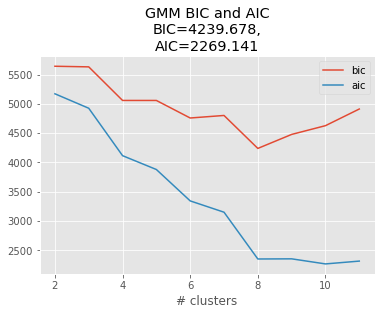

In [26]:
bics, aics = plot_bic_aic(X)

In [27]:
all_dfs = []
for f in [get_sc_pred, get_km_pred, get_gm_pred]:
    dfs = []
    for i in range(y.shape[1]):
        df = pd.DataFrame([get_score(k, f, X, y[:,i]) for k in range(2, no_clusters)],
                          columns=score_columns)
        dfs.append(df)
    all_dfs.append(dfs)

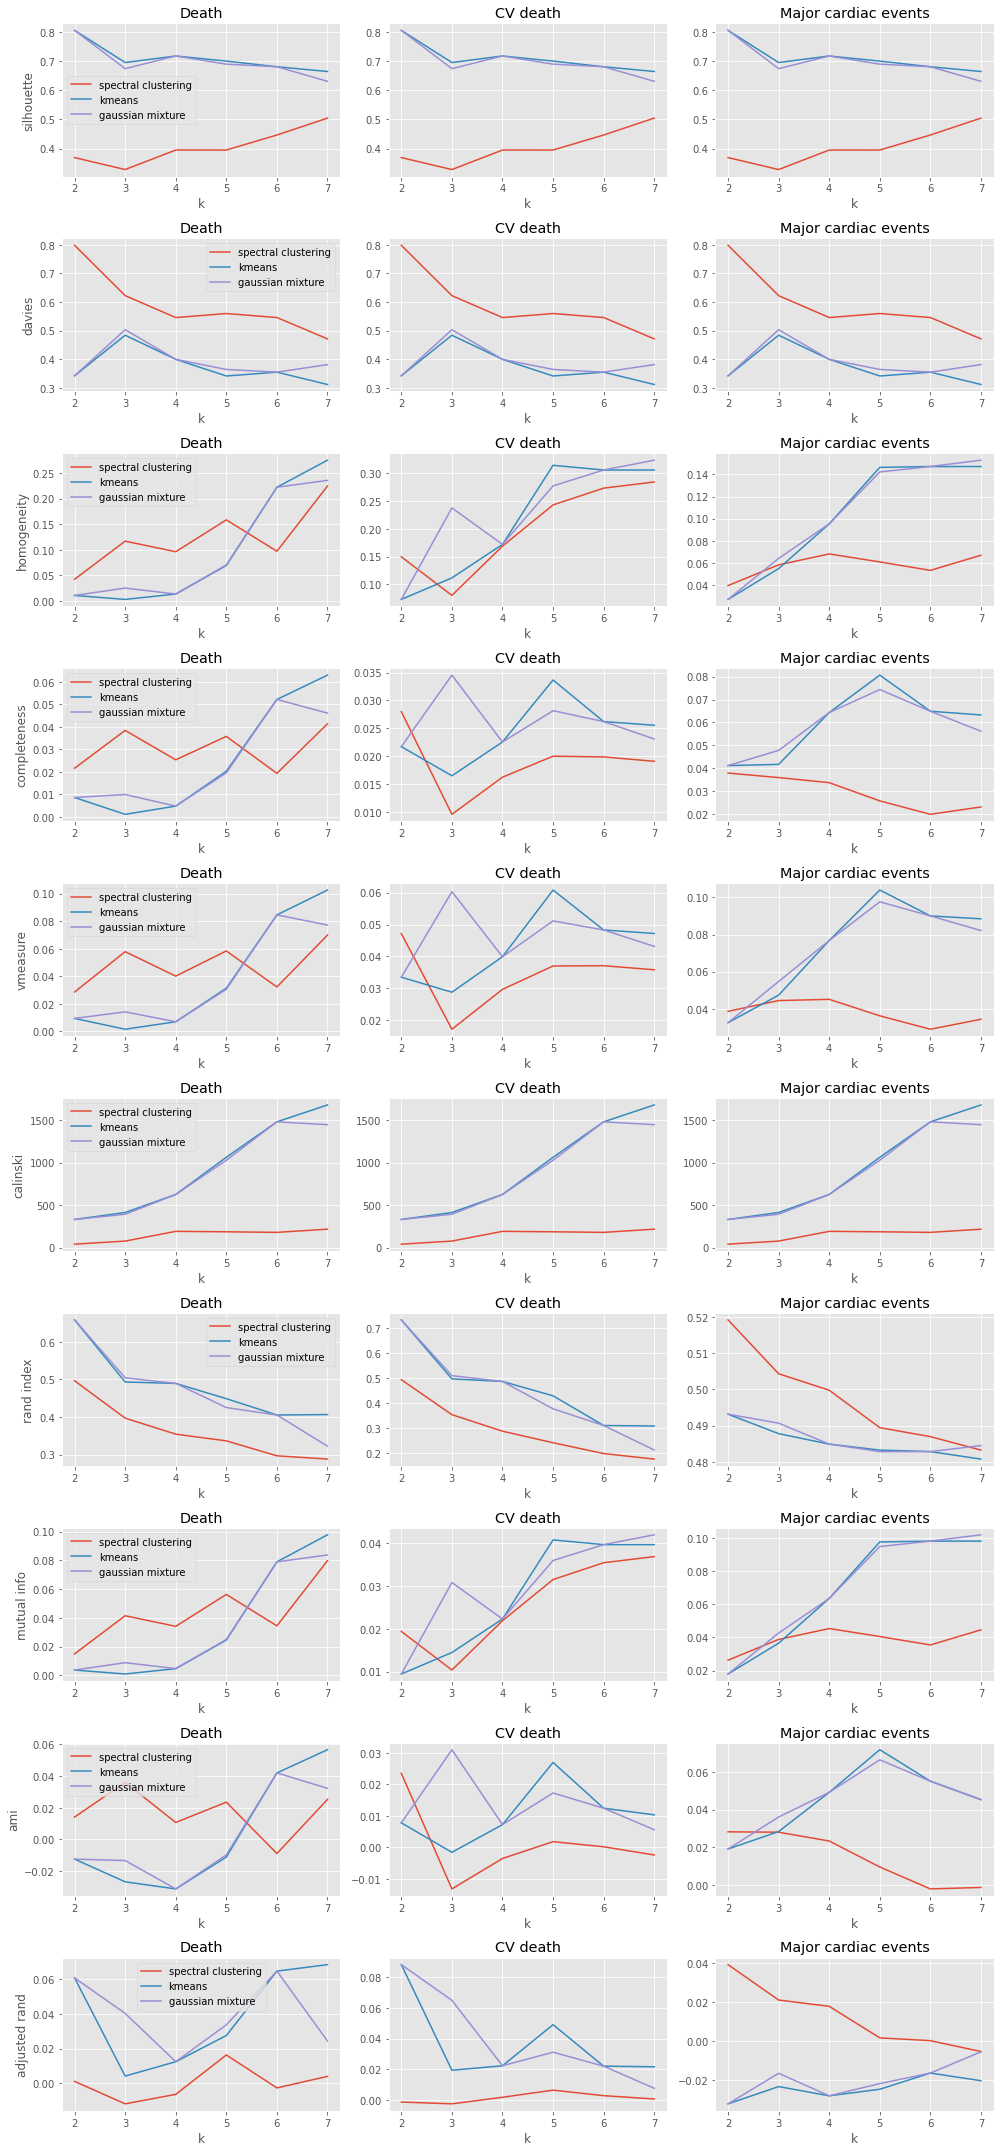

In [28]:
methods = ['spectral clustering', 'kmeans', 'gaussian mixture']

plot_clustering_score(all_dfs, methods, lbl_colname)

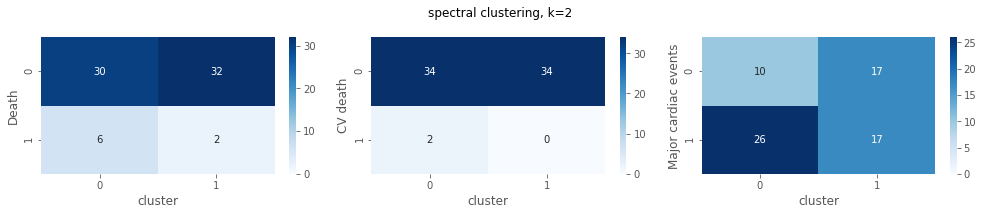

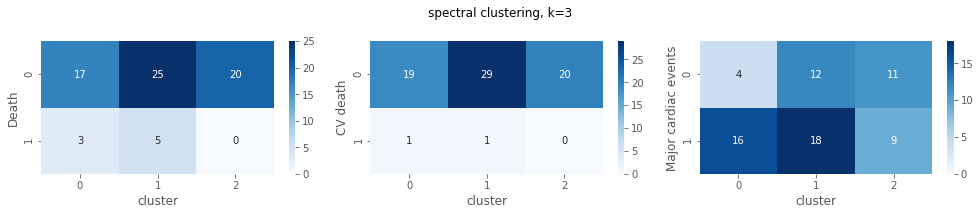

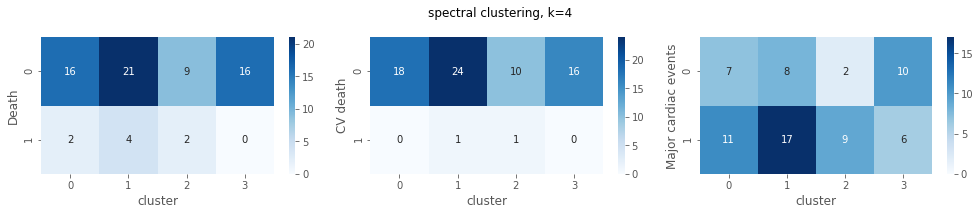

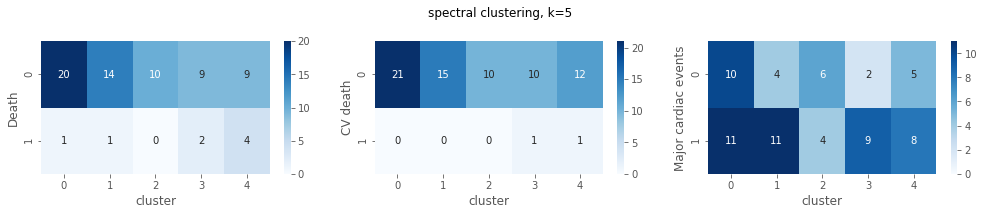

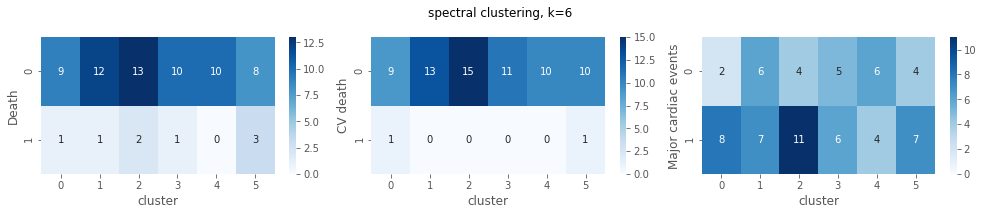

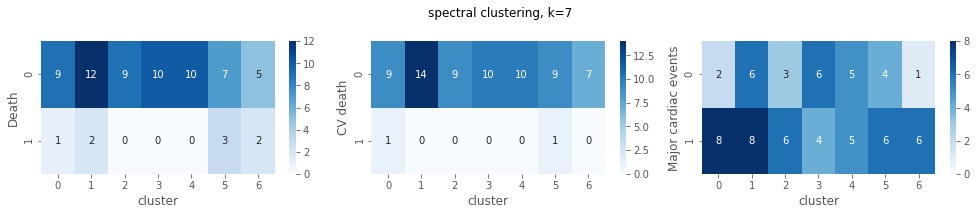

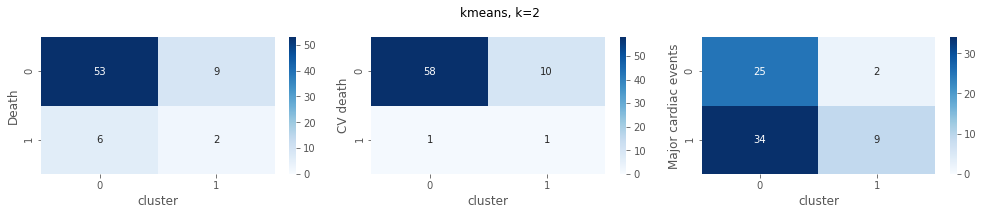

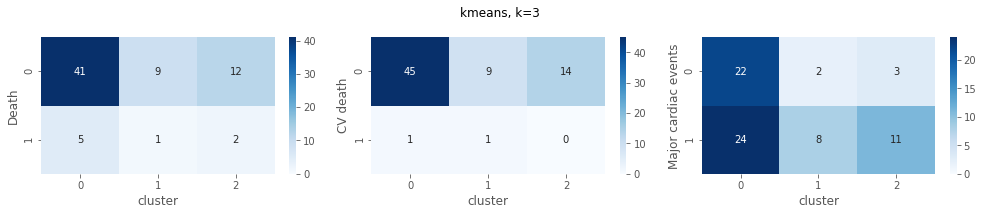

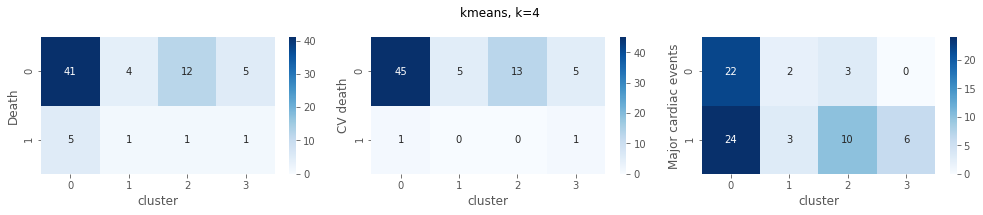

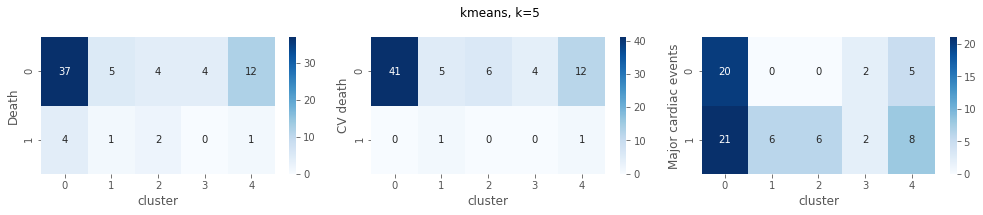

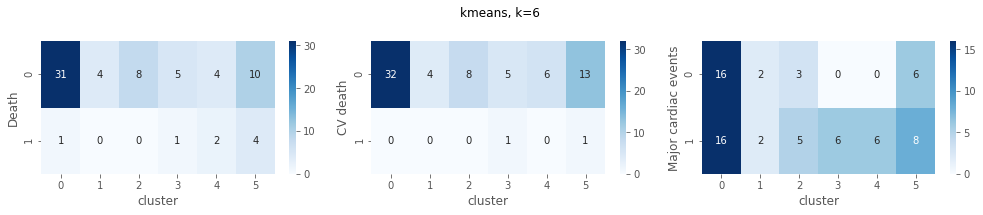

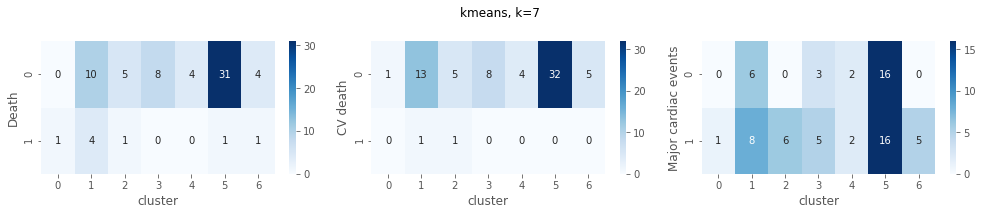

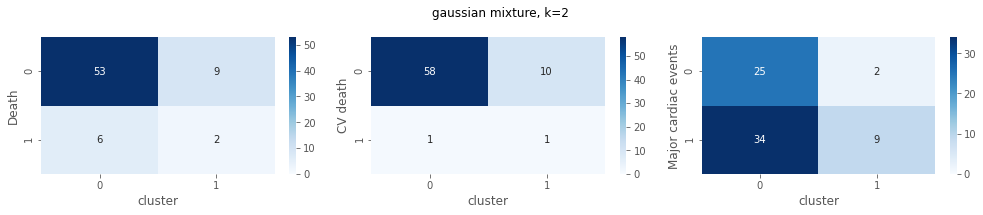

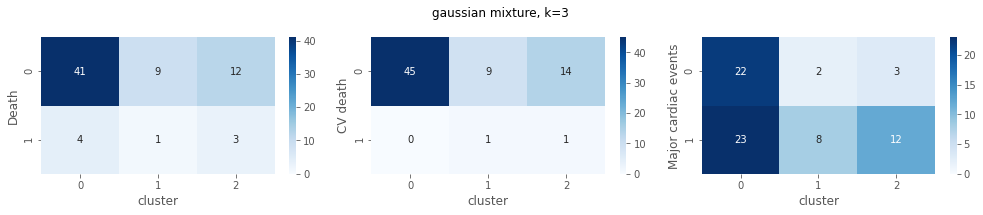

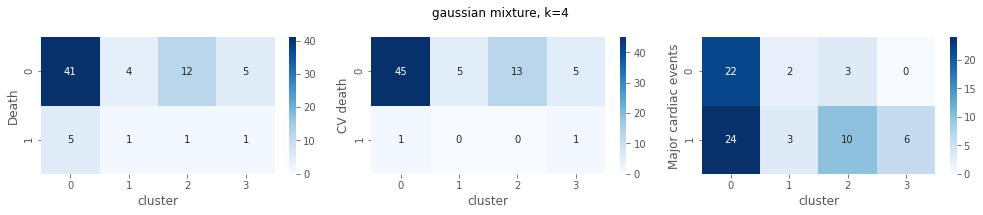

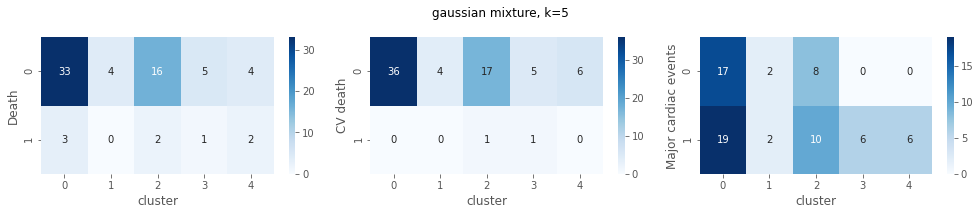

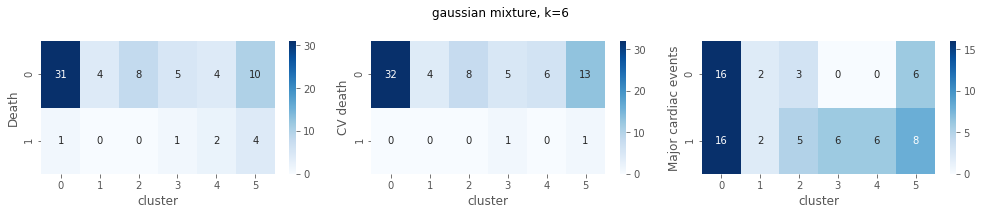

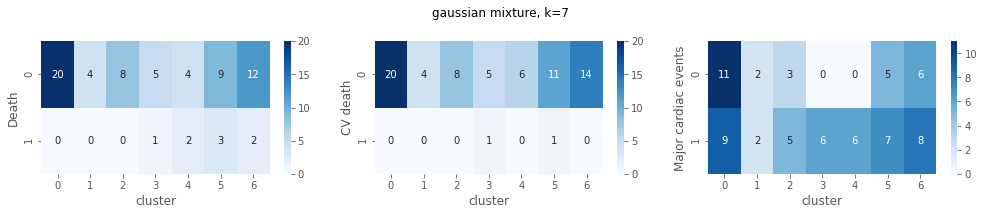

In [29]:
plot_contingency_matrix(all_dfs, methods, lbl_colname)

In [30]:
for i, lbl in enumerate(lbl_colname):
    display(lbl)
    for j, met in enumerate(methods):
        display(met)
        display(all_dfs[j][i])

'Death'

'spectral clustering'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.369361,0.798090,0.042215,0.021657,0.028628,41.523165,0.496480,0.015003,0.014120,0.001004,"[[30, 32], [6, 2]]","[36, 34]"
1,3,0.328290,0.622337,0.116807,0.038472,0.057881,77.766209,0.397101,0.041511,0.035999,-0.011972,"[[17, 25, 20], [3, 5, 0]]","[20, 30, 20]"
2,4,0.395297,0.545815,0.096095,0.025389,0.040166,191.773407,0.354451,0.034151,0.010702,-0.006481,"[[16, 21, 9, 16], [2, 4, 2, 0]]","[18, 25, 11, 16]"
3,5,0.395265,0.559884,0.158495,0.035814,0.058426,186.742934,0.336646,0.056326,0.023539,0.016277,"[[20, 14, 10, 9, 9], [1, 1, 0, 2, 4]]","[21, 15, 10, 11, 13]"
4,6,0.446765,0.545923,0.097035,0.019370,0.032293,179.844405,0.296894,0.034485,-0.008895,-0.002762,"[[9, 12, 13, 10, 10, 8], [1, 1, 2, 1, 0, 3]]","[10, 13, 15, 11, 10, 11]"
5,7,0.504756,0.471364,0.224619,0.041407,0.069924,217.419091,0.288199,0.079826,0.025247,0.003901,"[[9, 12, 9, 10, 10, 7, 5], [1, 2, 0, 0, 0, 3, 2]]","[10, 14, 9, 10, 10, 10, 7]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.805739,0.342491,0.010556,0.008626,0.009493,331.300979,0.658385,0.003751,-0.012436,0.060806,"[[53, 9], [6, 2]]","[59, 11]"
1,3,0.695379,0.484115,0.002833,0.001150,0.001636,413.240950,0.493168,0.001007,-0.026744,0.004074,"[[41, 9, 12], [5, 1, 2]]","[46, 10, 14]"
2,4,0.717800,0.399963,0.013350,0.004804,0.007065,624.480217,0.489441,0.004744,-0.031219,0.012377,"[[41, 4, 12, 5], [5, 1, 1, 1]]","[46, 5, 13, 6]"
3,5,0.700317,0.341821,0.069204,0.020314,0.031409,1061.091129,0.448861,0.024594,-0.011098,0.027513,"[[37, 5, 4, 4, 12], [4, 1, 2, 0, 1]]","[41, 6, 6, 4, 13]"
4,6,0.680903,0.355216,0.222240,0.052225,0.084575,1477.252542,0.405383,0.078980,0.041980,0.064744,"[[31, 4, 8, 5, 4, 10], [1, 0, 0, 1, 2, 4]]","[32, 4, 8, 6, 6, 14]"
5,7,0.664620,0.312222,0.275184,0.063056,0.102601,1675.373385,0.406625,0.097796,0.056613,0.068485,"[[0, 10, 5, 8, 4, 31, 4], [1, 4, 1, 0, 0, 1, 1]]","[1, 14, 6, 8, 4, 32, 5]"


...

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.369361,0.798090,0.039381,0.037906,0.038630,41.523165,0.519255,0.026259,0.028175,0.039015,"[[10, 17], [26, 17]]","[36, 34]"
1,3,0.328290,0.622337,0.058152,0.035937,0.044422,77.766209,0.504348,0.038776,0.027972,0.020951,"[[4, 12, 11], [16, 18, 9]]","[20, 30, 20]"
2,4,0.395297,0.545815,0.068017,0.033717,0.045085,191.773407,0.499793,0.045353,0.023291,0.017739,"[[7, 8, 2, 10], [11, 17, 9, 6]]","[18, 25, 11, 16]"
3,5,0.395265,0.559884,0.060786,0.025771,0.036196,186.742934,0.489441,0.040531,0.009458,0.001631,"[[10, 4, 6, 2, 5], [11, 11, 4, 9, 8]]","[21, 15, 10, 11, 13]"
4,6,0.446765,0.545923,0.053150,0.019906,0.028964,179.844405,0.486957,0.035440,-0.002219,0.000202,"[[2, 6, 4, 5, 6, 4], [8, 7, 11, 6, 4, 7]]","[10, 13, 15, 11, 10, 11]"
5,7,0.504756,0.471364,0.066836,0.023117,0.034352,217.419091,0.483230,0.044565,-0.001429,-0.005342,"[[2, 6, 3, 6, 5, 4, 1], [8, 8, 6, 4, 5, 6, 6]]","[10, 14, 9, 10, 10, 10, 7]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.805739,0.342491,0.026853,0.041171,0.032505,331.300979,0.493168,0.017905,0.019021,-0.032047,"[[25, 2], [34, 9]]","[59, 11]"
1,3,0.695379,0.484115,0.054762,0.041694,0.047343,413.240950,0.487785,0.036515,0.028320,-0.023240,"[[22, 2, 3], [24, 8, 11]]","[46, 10, 14]"
2,4,0.717800,0.399963,0.095264,0.064316,0.076789,624.480217,0.484886,0.063521,0.049198,-0.027949,"[[22, 2, 3, 0], [24, 3, 10, 6]]","[46, 5, 13, 6]"
3,5,0.700317,0.341821,0.146424,0.080644,0.104006,1061.091129,0.483230,0.097635,0.071882,-0.024603,"[[20, 0, 0, 2, 5], [21, 6, 6, 2, 8]]","[41, 6, 6, 4, 13]"
4,6,0.680903,0.355216,0.147164,0.064886,0.090062,1477.252542,0.482816,0.098128,0.055127,-0.016331,"[[16, 2, 3, 0, 0, 6], [16, 2, 5, 6, 6, 8]]","[32, 4, 8, 6, 6, 14]"
5,7,0.664620,0.312222,0.147164,0.063270,0.088494,1675.373385,0.480745,0.098128,0.045296,-0.020240,"[[0, 6, 0, 3, 2, 16, 0], [1, 8, 6, 5, 2, 16, 5]]","[1, 14, 6, 8, 4, 32, 5]"


'gaussian mixture'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.805739,0.342491,0.026853,0.041171,0.032505,331.300979,0.493168,0.017905,0.019021,-0.032047,"[[25, 2], [34, 9]]","[59, 11]"
1,3,0.674413,0.503428,0.063950,0.047798,0.054707,392.242774,0.490683,0.042641,0.036061,-0.016445,"[[22, 2, 3], [23, 8, 12]]","[45, 10, 15]"
2,4,0.717800,0.399963,0.095264,0.064316,0.076789,624.480217,0.484886,0.063521,0.049198,-0.027949,"[[22, 2, 3, 0], [24, 3, 10, 6]]","[46, 5, 13, 6]"
3,5,0.689811,0.364701,0.142256,0.074342,0.097652,1026.528082,0.482816,0.094855,0.066517,-0.021710,"[[17, 2, 8, 0, 0], [19, 2, 10, 6, 6]]","[36, 4, 18, 6, 6]"
4,6,0.680903,0.355216,0.147164,0.064886,0.090062,1477.252542,0.482816,0.098128,0.055127,-0.016331,"[[16, 2, 3, 0, 0, 6], [16, 2, 5, 6, 6, 8]]","[32, 4, 8, 6, 6, 14]"
5,7,0.631030,0.381615,0.152898,0.056179,0.082167,1444.050638,0.484472,0.101951,0.045326,-0.005514,"[[11, 2, 3, 0, 0, 5, 6], [9, 2, 5, 6, 6, 7, 8]]","[20, 4, 8, 6, 6, 12, 14]"
